In [1]:
import os.path
from glob import glob

%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib import colors
from matplotlib.offsetbox import AnchoredText
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import matplotlib.patches as patches

import xarray as xr
import numpy as np
from xhistogram.xarray import histogram

In [2]:
col_blue = (68/255,119/255,170/255)
col_cyan = (102/255,204/255,238/255)
col_green = (34/255,136/255,51/255)
col_yellow = (204/255,187/255,68/255)
col_red = (238/255,102/255,119/255)
col_purple = (170/255,51/255,119/255)
col_grey = (187/255, 187/255, 187/255)


###
#
def convert_col_alpha2opac(rgbcol, alpha):
    alpha2opac = 255 - alpha*(255-rgbcol)
    return alpha2opac



In [3]:
datapath1 = '/Users/siren/Data/IMMERSE/'
regionmaskpath = (datapath1 + 'domain/MEDregions.nc')
regionmask = xr.open_dataset(regionmaskpath).rename({'jm':'y','im':'x'})

In [4]:
gridpath = (datapath1 + 'domain/mesh_mask.nc')
grid = xr.open_dataset(gridpath, drop_variables=('x','y'))

In [5]:
Mask_MedSea_reload = xr.open_dataset(datapath1 + 'domain/Mask_MedSea.nc')


In [6]:
datapath = '/Users/siren/IMMERSE_waves/develop-mac/data/Trajectories-revisedNEMO/SubReg9/'
trajpaths_reg1 = sorted(glob(f'{datapath}Parcels_CalcTraj_Data-coupled-sd_Release-SubReg9-t*_Integrate-fw-d30-dt25m_Sample-UV.zarr/'),
                        key=lambda f: int(''.join(filter(str.isdigit, f))))
traj_reg1 = xr.open_mfdataset(trajpaths_reg1,
                              concat_dim="start", combine="nested",
                              engine="zarr")

datapath = '/Users/siren/IMMERSE_waves/develop-mac/data/Trajectories-revisedNEMO/GulfOfLion/'
trajpaths_reg2 = sorted(glob(f'{datapath}Parcels_CalcTraj_Data-coupled-sd_Release-GulfOfLion-t*_Integrate-fw-d30-dt25m_Sample-UV.zarr/'),
                        key=lambda f: int(''.join(filter(str.isdigit, f))))
traj_reg2 = xr.open_mfdataset(trajpaths_reg2,
                              concat_dim="start", combine="nested",
                              engine="zarr")

datapath = '/Users/siren/IMMERSE_waves/develop-mac/data/Trajectories-revisedNEMO/SubReg14/'
trajpaths_reg3 = sorted(glob(f'{datapath}Parcels_CalcTraj_Data-coupled-sd_Release-SubReg14-t*_Integrate-fw-d30-dt25m_Sample-UV.zarr/'),
                        key=lambda f: int(''.join(filter(str.isdigit, f))))
traj_reg3 = xr.open_mfdataset(trajpaths_reg3,
                              concat_dim="start", combine="nested",
                              engine="zarr")

In [7]:
tmp = regionmask.regs.copy()

for i in [4,14]:
    tmp = tmp.where((regionmask.regs != i), other=-3)

for i in [2,6,7,8,9,10,11,13,15,16]:
    tmp = tmp.where((regionmask.regs != i), other=-2)

for i in [1,3,5,12]:
    tmp = tmp.where((regionmask.regs != i), other=-1)

regionmask2 = tmp.where(Mask_MedSea_reload.Mask_MedSea == 1)

In [8]:
lonmin_plot = -7
lonmax_plot = 36
latmin_plot = 30.5
latmax_plot = 46
xticks = [0,10,20,30]
yticks = [35,40,45]
xticklabs = ['0° E','10° E','20° E', '30° E']
yticklabs = ['35° N','40° N','45° N']

fs='xx-small'

def calc_reg_ave(var):
    var_rave = var.copy()*0
    var_rave_slim_list = []
    for i in range(17):
        reg = float(i + 1)
        regmask = regionmask.regs.assign_coords({'nav_lon':var.nav_lon, 'nav_lat':var.nav_lat})
        tmp0 = var.where(Mask_MedSea_reload.Mask_MedSea == 1)
        tmp = tmp0.where(regionmask.regs == reg).mean(dim=['x','y'], skipna=True)
        tmp2 = (var.where(regionmask.regs == reg)*0 + tmp).fillna(0)
        var_rave = var_rave + tmp2
        var_rave_slim_list.append(tmp)
    var_rave_slim = xr.concat(var_rave_slim_list, dim='regs').assign_coords({'regs':np.arange(17)+1})
    return var_rave, var_rave_slim


def plot_bathy():
    var = grid.umaskutil
    var.rename({'x':'lon', 'y':'lat'})
    colors = [(0.5, 0.5, 0.5),(0.5,0.5,0.5)] 
    cmap_name = 'landgrey'
    cmapland = LinearSegmentedColormap.from_list(cmap_name, colors)
    map = plt.pcolor(grid.glamu.isel(time_counter=0), grid.gphiu.isel(time_counter=0),
                     var.where(var!=1).isel(time_counter=0),
                     cmap = cmapland, 
                     shading='nearest')

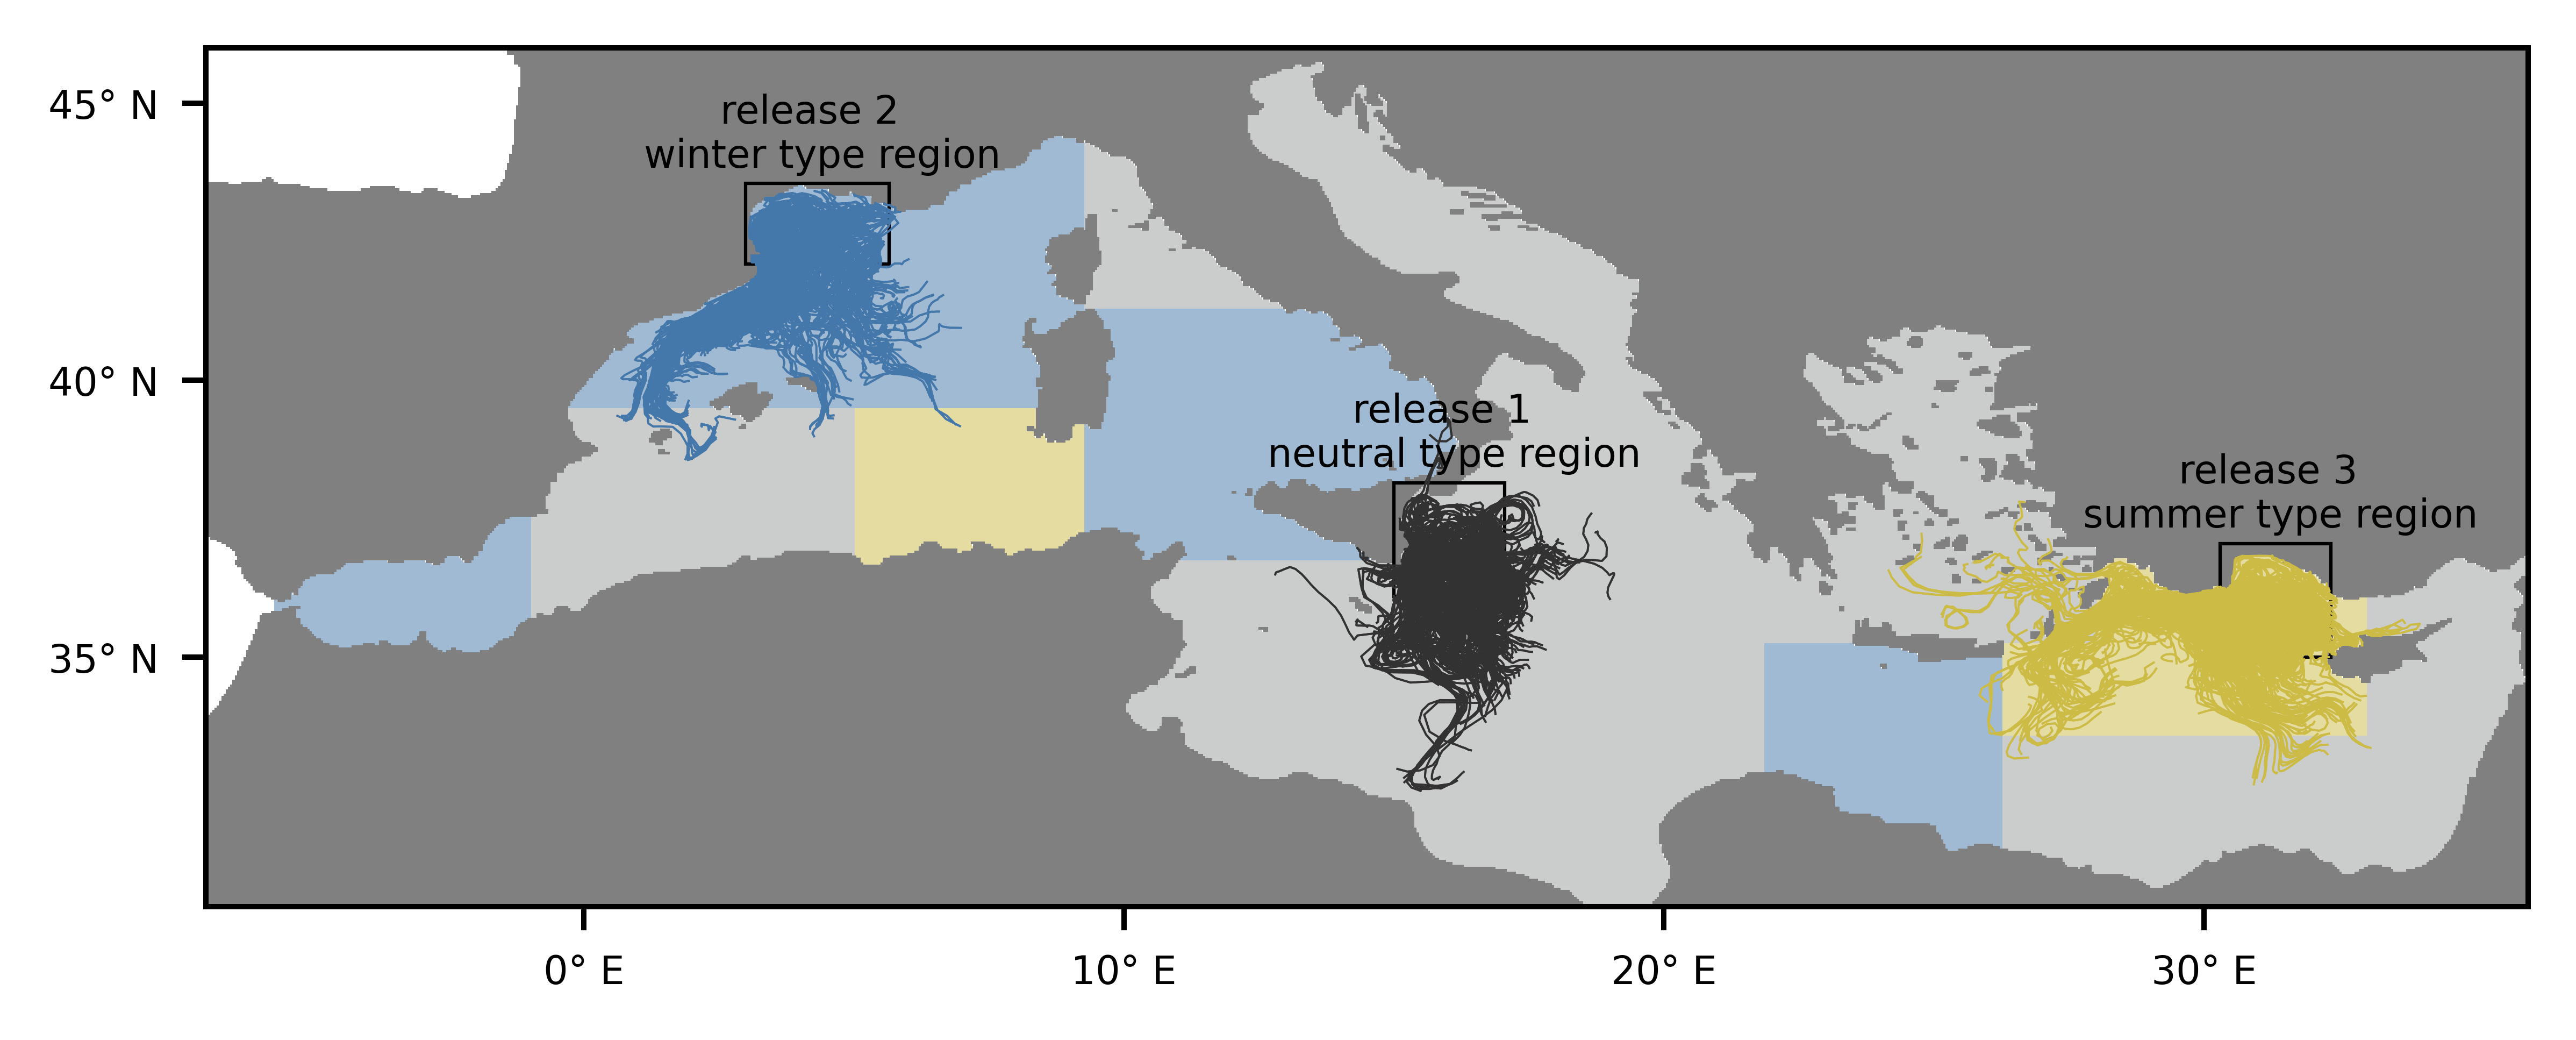

In [9]:
def plot_trajectories(release_name):

    if release_name == 'GulfOfLion':
        traj_csd = traj_reg2
        traj_col = col_blue #'darkblue'
    if release_name == 'SubReg14':
        traj_csd = traj_reg3
        traj_col = col_yellow #'darkkhaki'
    if release_name == 'SubReg9':
        traj_csd = traj_reg1
        traj_col = (50/255, 50/255, 50/255)

    for i in np.arange(0,1100,10):
        for j in np.arange(0,72,18):
            plt.plot(traj_csd.lon.isel(start=j, trajectory=i), traj_csd.lat.isel(start=j, trajectory=i), color=traj_col, linewidth=0.3)
            plt.plot(traj_csd.lon.isel(start=j, trajectory=i), traj_csd.lat.isel(start=j, trajectory=i), color=traj_col, linewidth=0.3)

def plot_releasebox(release_name):
    if release_name == 'GulfOfLion':
        lonmin = 3
        lonmax = 5.6
        latmin = 42.1
        latmax = 43.5
        step = 0.05 #(appr. every grid cell)
        ax.text(lonmin+(lonmax-lonmin)/2,latmax+0.2,'release 2 \n winter type region',
                va = 'bottom', ha= 'center',
                fontsize=fs)

    if release_name == 'SubReg14':
        lonmin = 30.3
        lonmax = 32.3
        latmin = 35
        latmax = 37
        step = 0.05 #(appr. every 5th grid cell)
        ax.text(lonmin+(lonmax-lonmin)/2,latmax+0.2,'release 3 \n summer type region',
                va = 'bottom', ha= 'center',
                fontsize=fs)

    if release_name == 'SubReg7':
        lonmin = 10
        lonmax = 12
        latmin = 33
        latmax = 35.3
        step = 0.05 #(appr. every 5th grid cell)
        ax.text(lonmin+(lonmax-lonmin)/2,latmin-0.2,'release 1 \n neutral type region',
                va = 'top', ha= 'center',
                fontsize=fs)
        
    if release_name == 'SubReg9':
        lonmin = 15.0
        lonmax = 17.0
        latmin = 36.1
        latmax = 38.1
        step = 0.05 #(appr. every grid cell)
        ax.text(lonmin+(lonmax-lonmin)/2,latmax+0.2,'release 1 \n neutral type region',
                va = 'bottom', ha= 'center',
                fontsize=fs)

    rect = patches.Rectangle((lonmin, latmin), lonmax-lonmin+step, latmax-latmin+step, 
                             linewidth=0.5,edgecolor='k', facecolor='none')
    ax.add_patch(rect)


fig = plt.figure(figsize=(6,6), dpi=900, constrained_layout=False)

gs = fig.add_gridspec(nrows=6, ncols=3, 
                      left=0.1, right=0.9,
                      wspace=0.03, hspace=0.07)
gs2 = fig.add_gridspec(nrows=5, ncols=5, 
                      left=0.1, right=0.9,
                      wspace=0.05, hspace=0.15)

ax = fig.add_subplot(gs2[0:2,0:6])

alpha = 0.5
#col_blue = (68/255,119/255,170/255)
#col_blue_alpha = (68/255,119/255,170/255,alpha)
#col_cyan = (102/255,204/255,238/255)
#col_green = (34/255,136/255,51/255)
#col_yellow = (204/255,187/255,68/255)
#col_yellow_alpha = (204/255,187/255,68/255,alpha)
#col_red = (238/255,102/255,119/255)
#col_purple = (170/255,51/255,119/255)
#col_grey = (187/255, 187/255, 187/255)
#col_grey_alpha = (187/255, 187/255, 187/255,alpha)
#col_black_alpha = (0,0,0,0.65)

ccolors = [(68/255,119/255,170/255,alpha), (0.8,0.8,0.8), (204/255,187/255,68/255,alpha)]
#ccolors = [(0.4, 0.6, 0.8),(0.8,0.8,0.8),(0.9,0.9,0.7)] 
cmap_name = 'colregs2'
cmapregs = LinearSegmentedColormap.from_list(cmap_name, ccolors)
colmregs = cmapregs
#colm = cm.terrain
levs = np.arange(1,5,1)
normregs = colors.BoundaryNorm(boundaries=levs, ncolors=colmregs.N)

map = plt.pcolor(regionmask.lon, regionmask.lat,
                 regionmask2 *(-1),
                 cmap=colmregs, norm=normregs,
                 shading='nearest', snap=True)
plot_bathy()
plot_trajectories("GulfOfLion")
plot_trajectories("SubReg14")
plot_trajectories("SubReg9")
plot_releasebox("GulfOfLion")
plot_releasebox('SubReg14')
plot_releasebox('SubReg9')
#add_regnumbers()
ax.set_xlim([lonmin_plot,lonmax_plot])
ax.set_ylim([latmin_plot,latmax_plot])
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(xticklabs)
ax.set_yticklabels(yticklabs)
ax.tick_params(axis='both', labelsize=fs)

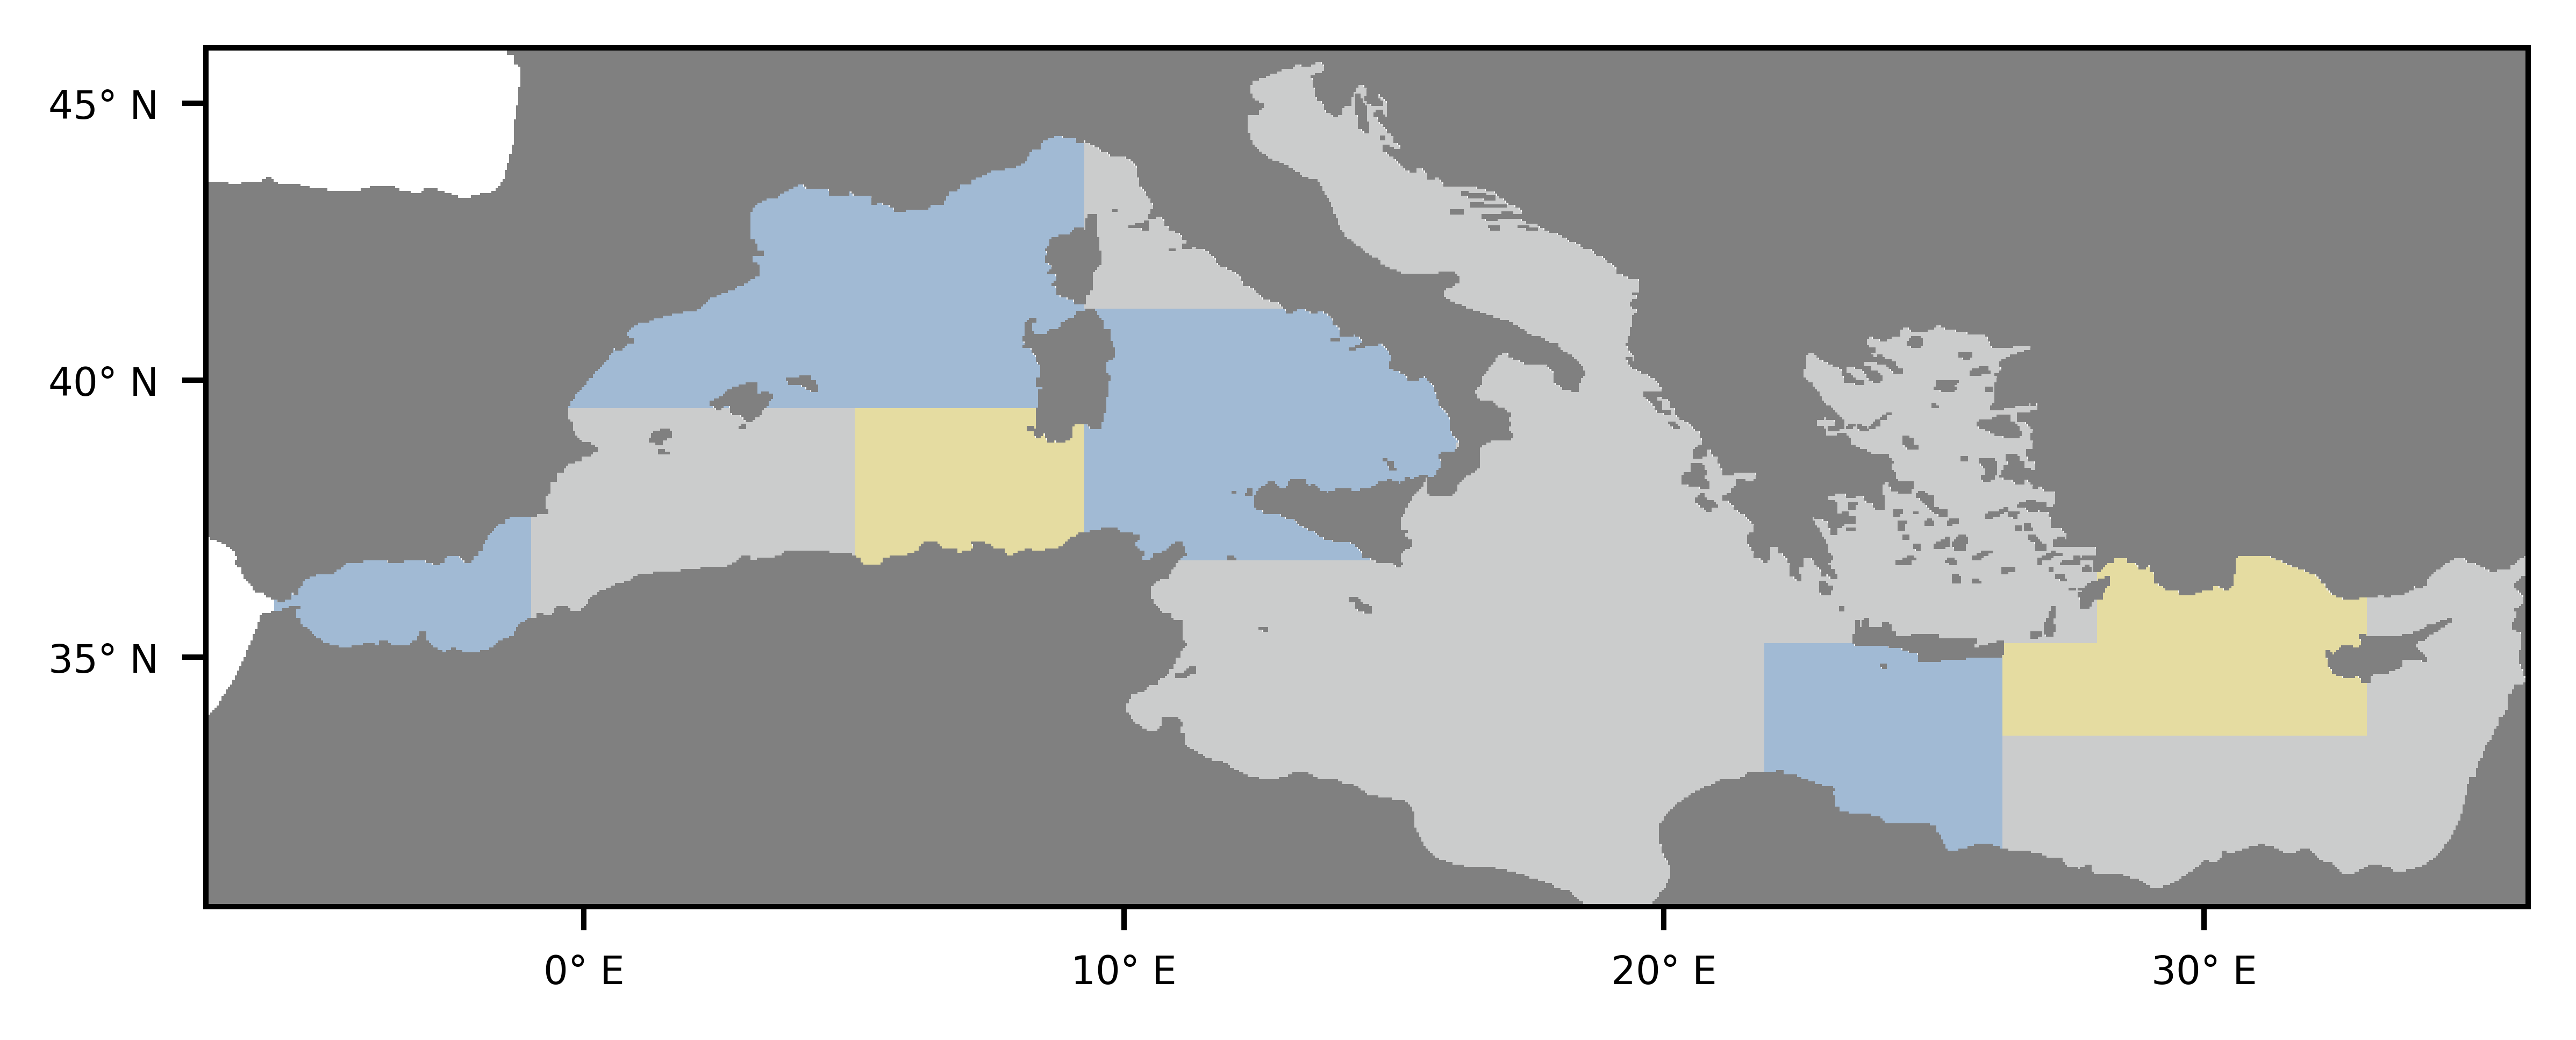

In [12]:
fig = plt.figure(figsize=(6,6), dpi=900, constrained_layout=False)

gs = fig.add_gridspec(nrows=6, ncols=3, 
                      left=0.1, right=0.9,
                      wspace=0.03, hspace=0.07)
gs2 = fig.add_gridspec(nrows=5, ncols=5, 
                      left=0.1, right=0.9,
                      wspace=0.05, hspace=0.15)

ax = fig.add_subplot(gs2[0:2,0:6])

alpha = 0.5
#col_blue = (68/255,119/255,170/255)
#col_blue_alpha = (68/255,119/255,170/255,alpha)
#col_cyan = (102/255,204/255,238/255)
#col_green = (34/255,136/255,51/255)
#col_yellow = (204/255,187/255,68/255)
#col_yellow_alpha = (204/255,187/255,68/255,alpha)
#col_red = (238/255,102/255,119/255)
#col_purple = (170/255,51/255,119/255)
#col_grey = (187/255, 187/255, 187/255)
#col_grey_alpha = (187/255, 187/255, 187/255,alpha)
#col_black_alpha = (0,0,0,0.65)

ccolors = [(68/255,119/255,170/255,alpha), (0.8,0.8,0.8), (204/255,187/255,68/255,alpha)]
#ccolors = [(0.4, 0.6, 0.8),(0.8,0.8,0.8),(0.9,0.9,0.7)] 
cmap_name = 'colregs2'
cmapregs = LinearSegmentedColormap.from_list(cmap_name, ccolors)
colmregs = cmapregs
#colm = cm.terrain
levs = np.arange(1,5,1)
normregs = colors.BoundaryNorm(boundaries=levs, ncolors=colmregs.N)

map = plt.pcolor(regionmask.lon, regionmask.lat,
                 regionmask2 *(-1),
                 cmap=colmregs, norm=normregs,
                 shading='nearest', snap=True)
plot_bathy()
#plot_trajectories("GulfOfLion")
#plot_trajectories("SubReg14")
#plot_trajectories("SubReg9")
#plot_releasebox("GulfOfLion")
#plot_releasebox('SubReg14')
#plot_releasebox('SubReg9')
ax.set_xlim([lonmin_plot,lonmax_plot])
ax.set_ylim([latmin_plot,latmax_plot])
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(xticklabs)
ax.set_yticklabels(yticklabs)
ax.tick_params(axis='both', labelsize=fs)

In [10]:
Mask_MedSea_reload.Mask_MedSea

<xarray.DataArray 'Mask_MedSea' (y: 380, x: 1307)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    z        float32 ...
    nav_lon  (y, x) float32 ...
    nav_lat  (y, x) float32 ...
Dimensions without coordinates: y, x

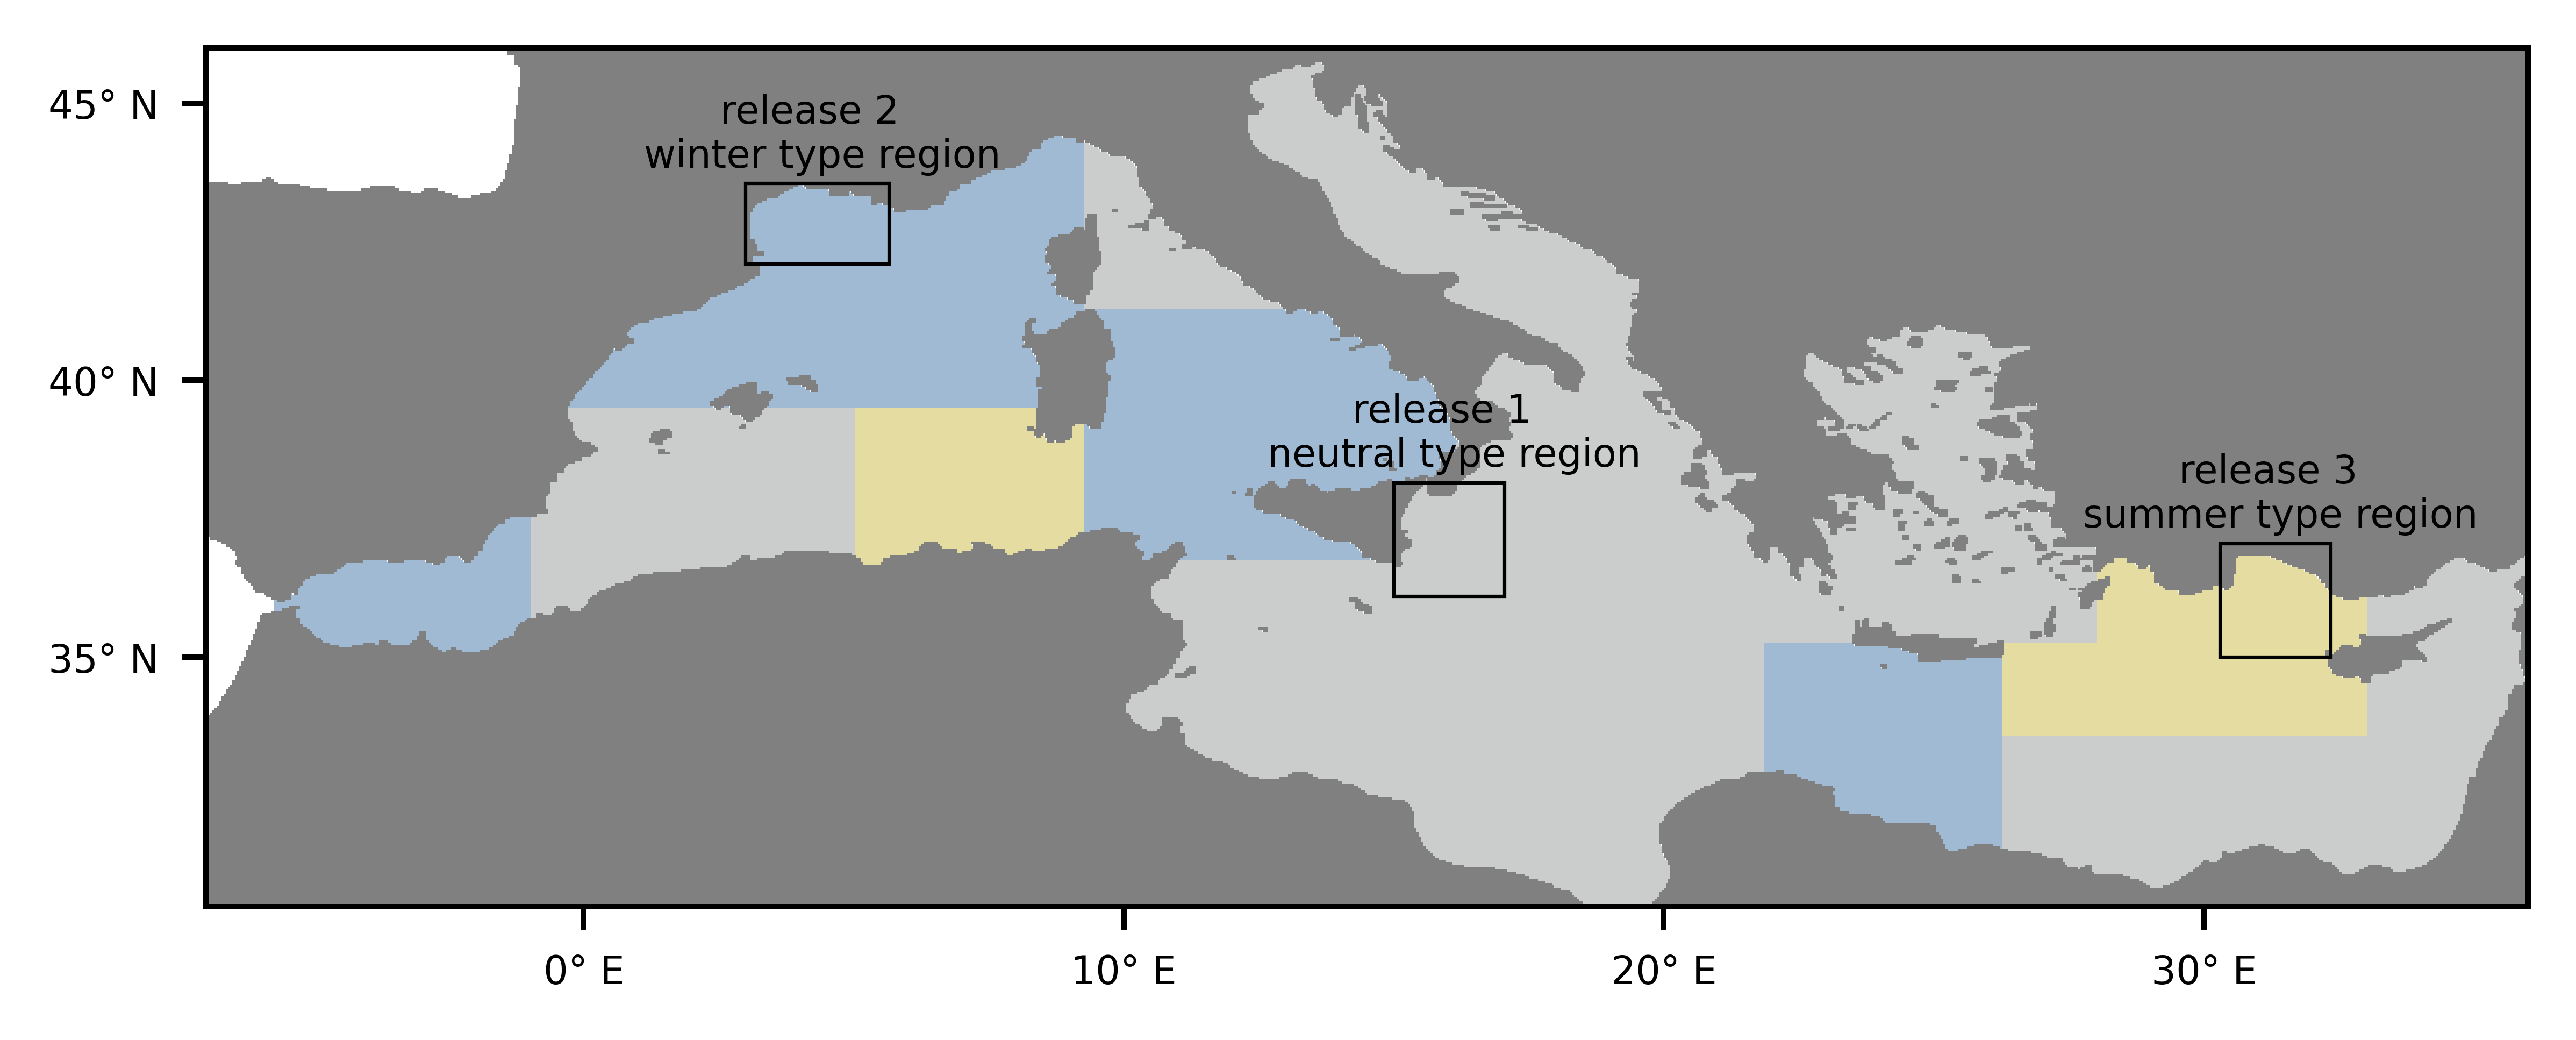

In [13]:
fig = plt.figure(figsize=(6,6), dpi=900, constrained_layout=False)

gs = fig.add_gridspec(nrows=6, ncols=3, 
                      left=0.1, right=0.9,
                      wspace=0.03, hspace=0.07)
gs2 = fig.add_gridspec(nrows=5, ncols=5, 
                      left=0.1, right=0.9,
                      wspace=0.05, hspace=0.15)

ax = fig.add_subplot(gs2[0:2,0:6])

alpha = 0.5
#col_blue = (68/255,119/255,170/255)
#col_blue_alpha = (68/255,119/255,170/255,alpha)
#col_cyan = (102/255,204/255,238/255)
#col_green = (34/255,136/255,51/255)
#col_yellow = (204/255,187/255,68/255)
#col_yellow_alpha = (204/255,187/255,68/255,alpha)
#col_red = (238/255,102/255,119/255)
#col_purple = (170/255,51/255,119/255)
#col_grey = (187/255, 187/255, 187/255)
#col_grey_alpha = (187/255, 187/255, 187/255,alpha)
#col_black_alpha = (0,0,0,0.65)

ccolors = [(68/255,119/255,170/255,alpha), (0.8,0.8,0.8), (204/255,187/255,68/255,alpha)]
#ccolors = [(0.4, 0.6, 0.8),(0.8,0.8,0.8),(0.9,0.9,0.7)] 
cmap_name = 'colregs2'
cmapregs = LinearSegmentedColormap.from_list(cmap_name, ccolors)
colmregs = cmapregs
#colm = cm.terrain
levs = np.arange(1,5,1)
normregs = colors.BoundaryNorm(boundaries=levs, ncolors=colmregs.N)

map = plt.pcolor(regionmask.lon, regionmask.lat,
                 regionmask2 *(-1),
                 cmap=colmregs, norm=normregs,
                 shading='nearest', snap=True)
plot_bathy()
#plot_trajectories("GulfOfLion")
#plot_trajectories("SubReg14")
#plot_trajectories("SubReg9")
plot_releasebox("GulfOfLion")
plot_releasebox('SubReg14')
plot_releasebox('SubReg9')
ax.set_xlim([lonmin_plot,lonmax_plot])
ax.set_ylim([latmin_plot,latmax_plot])
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels(xticklabs)
ax.set_yticklabels(yticklabs)
ax.tick_params(axis='both', labelsize=fs)